In [1]:
"""Scripts for analyzing of phantom outputs.

This script generate lightcurves (LC) by doing radiative transfer on a grid generated by splash to grid.


-------------------------------------------------------------------------------

Side note: Remember to limit line length to 79 characters according to PEP-8
    https://peps.python.org/pep-0008/#maximum-line-length    
which is the length of below line of '-' characters.

-------------------------------------------------------------------------------

"""

"Scripts for analyzing of phantom outputs.\n\nThis script generate lightcurves (LC) by doing radiative transfer on a grid generated by splash to grid.\n\n\n-------------------------------------------------------------------------------\n\nSide note: Remember to limit line length to 79 characters according to PEP-8\n    https://peps.python.org/pep-0008/#maximum-line-length    \nwhich is the length of below line of '-' characters.\n\n-------------------------------------------------------------------------------\n\n"

.

## Def

.

In [2]:
import numpy as np
from numpy import pi
from astropy import units
from astropy import constants as const
import matplotlib.pyplot as plt
from matplotlib.typing import ColorType
import matplotlib as mpl
from numba import jit,njit, prange
import sarracen
import itertools
from scipy import integrate, fft
from scipy.spatial import kdtree
from scipy.optimize import curve_fit
from datetime import datetime
import os
from os.path import sep
# fix weird moviepy cannot find my ffmpeg exe error
try: import moviepy
except RuntimeError: os.environ["IMAGEIO_FFMPEG_EXE"] = "/usr/bin/ffmpeg"
try: from moviepy import ImageSequenceClip, concatenate_videoclips
except ImportError: from moviepy.editor import ImageSequenceClip, concatenate_videoclips
import gc
#from os import path

In [3]:
# import my modules listed in ./main/

import clmuphantomlib as mupl
from clmuphantomlib            import MyPhantomDataFrames, get_eos, get_eos_opacity
from clmuphantomlib.log        import is_verbose, say
from clmuphantomlib.settings   import DEFAULT_SETTINGS as settings
from clmuphantomlib.units_util import get_val_in_unit, set_as_quantity #, get_units_field_name, get_units_cgs
from clmuphantomlib.io         import json_dump, json_load, hdf5_dump, hdf5_load
from clmuphantomlib.eos.mesa   import EoS_MESA_opacity
from clmuphantomlib.light      import get_optical_depth_by_ray_tracing_3D, get_photosphere_on_ray

from multiprocessing import cpu_count, Pool #Process, Queue
NPROCESSES = 1 if cpu_count() is None else max(cpu_count(), 1)

In [4]:
# settings
#
#   imported from script_input.py file


from script_LCGen__input import verbose, verbose_loop, interm_dir, output_dir, unitsOut, SPEC_DIST, PHOTOSPHERE_TAU, JOB_PROFILES_DICT
from _sharedFuncs import mpdf_read, pa_read_energy, pa_read_ev

# remove temp flag
interm_dir = interm_dir.split('test_')[0]
interm_dir = interm_dir.split('Tscale_')[0]
interm_dir = interm_dir.split('Tcut_')[0]
interm_dir = interm_dir.split('Tdelete_')[0]
# interm_dir = interm_dir.split('olim_')[0]


unitsOutTxt = {  key  : unitsOut[key].to_string('latex_inline') for key in unitsOut.keys() }

spec_dist = SPEC_DIST

# set metadata
with open("_metadata__input.json", 'r') as f:
    metadata = json_load(f)
metadata['Title'] = "Getting light curves by intergrating across a grid of rays"
metadata['Description'] = f"""Getting light curves by intergrating across a grid of rays with the same directions
for dump file data generated by phantom
"""


plt.rcParams.update({'font.size': 20})
if __name__ == '__main__' and is_verbose(verbose, 'note'):
    # remember to check if name is '__main__' if you wanna say anything
    #    so when you do multiprocessing the program doesn't freak out
    say('note', None, verbose, f"{interm_dir = }")
    say('note', None, verbose, f"Will use {NPROCESSES} processes for parallelization")


*   Note   :    run_ast_nodes() ==> run_code() ==> <module>():
	interm_dir = '../interm/'
*   Note   :    run_ast_nodes() ==> run_code() ==> <module>():
	Will use 8 processes for parallelization


In [5]:
from clmuphantomlib.log import say, is_verbose
from clmuphantomlib.geometry import get_dist2_between_2pt, get_closest_pt_on_line
from clmuphantomlib.sph_interp import get_sph_interp, get_h_from_rho, get_no_neigh, _get_sph_interp_phantom_np
from clmuphantomlib.units_util import set_as_quantity, set_as_quantity_temperature, get_units_field_name, DEFAULT_UNITS
from clmuphantomlib.eos   import EoS_Base
from clmuphantomlib.light import integrate_along_ray_grid, integrate_along_ray_gridxy

#  import (general)
import numpy as np
import numba
from numba import jit, njit, prange
import sarracen
from scipy.stats import linregress

from clmuphantomlib.geometry import get_dist2_from_pts_to_line, get_dist2_from_pt_to_line_nb, get_ray_unit_vec, get_rays_unit_vec

## Main

In [6]:
# params

nn = '2md'
file_index = 2000
lims = (((-800, 400), (-600, 600), (-600, 600)) * units.Rsun).cgs    # 2md_00000 / 00020
# lims = (((-17495.706940, 13433.243545), (-15367.871312, 11505.372128), (-17489.000555, 16935.922291)) * units.Rsun).cgs    # 2md_02000
kappa_gas : units.Quantity = 2e-4*(units.cm**2/units.g)
T_cond_oxy: units.Quantity = 1450 * units.K

job_profile = JOB_PROFILES_DICT[nn]
eos_opacity = get_eos_opacity(ieos=job_profile['ieos'], params=job_profile['params'])
eos = get_eos(job_profile['ieos'], job_profile['params'])
dump_filename = f"{job_profile['job_name']}_{file_index:05}"

def read_splash_togrid_dat(fname):
    npixs = tuple(np.loadtxt(fname, max_rows=1).astype(int).tolist())
    return np.loadtxt(fname, skiprows=22).reshape(npixs)

In [7]:
# load text data and dump as hdf5

do_txt_to_hdf5 = False
if do_txt_to_hdf5:
    data = {}
    data['lims'] = lims
    data['rhos'] = read_splash_togrid_dat(f"{dump_filename}_density_g_cm3_grid.dat") * (units.g/units.cm**3)
    # data['Ts'] = read_splash_togrid_dat(f"{dump_filename}_temperature_K_grid.dat") * (units.K)
    data['us'] = read_splash_togrid_dat(f"{dump_filename}_u_erg_g_grid.dat") * (units.erg/units.g)
    data['Ts'] = eos.get_temp(rho=data['rhos'], u=data['us'])
    # opacities
    kappa_phantom = read_splash_togrid_dat(f"{dump_filename}_kappa_cm2_g_grid.dat") * (units.cm**2/units.g)
    kappa_dust = np.where(
        kappa_phantom < kappa_gas,
        0.*(units.cm**2/units.g),
        kappa_phantom - kappa_gas,
    )
    kappa_mesa = eos_opacity.get_kappa(data['rhos'], data['Ts'], do_extrap=False)
    data['kappas'] = np.where(
        data['Ts'] < T_cond_oxy,
        kappa_phantom,
        kappa_dust + kappa_mesa,
    ).cgs
    data['kappas'] = np.where(
        np.isnan(data['kappas']),
        0.,
        data['kappas'],
    )
    
    hdf5_dump(data, f"{dump_filename}__grid.hdf5")
else:
    data = hdf5_load(f"{dump_filename}__grid.hdf5")
    lims = data['lims']
    print(f"Overriding lims with '{data['lims']}'...")


data['Ts'] = np.where(np.isnan(data['Ts']), 0, data['Ts'])
xs1, ys1, zs1 = [np.linspace(data['lims'][iaxis, 0], data['lims'][iaxis, 1], data['rhos'].shape[iaxis]) for iaxis in range(3)]

*   Note   :    run_code() ==> <module>() ==> hdf5_load():
	Reading from ../raw/luis_2md/light_02000__grid.hdf5  (compress=False)
Overriding lims with '[[-1.21717633e+15  9.34550753e+14]
 [-1.06914281e+15  8.00428739e+14]
 [-1.21670977e+15  1.17823211e+15]] cm'...


In [ ]:
# calc LC

x_axis, y_axis, z_axis = 0, 1, 2

npixs = data['rhos'].shape
dz   = (lims[z_axis][1] - lims[z_axis][0]) / (npixs[z_axis]-1)
dAxy = (lims[x_axis][1] - lims[x_axis][0]) * (lims[y_axis][1] - lims[y_axis][0]) / ((npixs[x_axis]-1) * (npixs[y_axis]-1))

dtaus_z = data['rhos'] * data['kappas'] * dz
taus_z = np.cumsum(dtaus_z, axis=z_axis)
factors_z = np.exp(-taus_z) * dtaus_z
Ss = (const.sigma_sb / pi * data['Ts']**4).cgs
Is = np.sum(Ss*factors_z, axis=z_axis)
L = np.sum(Is * dAxy) * 4 * pi

L.to(units.Lsun)

### compare with my results

In [9]:
# compare with my results

xyz = 'xyz'

clmu_data = hdf5_load(f"../interm/{job_profile['nickname']}_{file_index:05d}.lcgen.256x256.hdf5")

clmu_data[xyz]['lum'], clmu_data[xyz]['lum_err'], clmu_data[xyz]['lum_olim']

*   Note   :    run_code() ==> <module>() ==> hdf5_load():
	Reading from ../interm/2md_02000.lcgen.256x256.hdf5  (compress=False)


(<Quantity 32713.1012692 solLum>,
 <Quantity 1062.82065595 solLum>,
 <Quantity 27583.75441616 solLum>)

In [10]:
np.max(data['rhos']), np.max(data['Ts']), np.max(data['kappas'])

(<Quantity 9.507896e-07 g / cm3>,
 <Quantity 215848.48392803 K>,
 <Quantity 79.91547589 cm2 / g>)

In [11]:
np.min(data['rhos']), np.min(data['Ts']), np.min(data['kappas'])

(<Quantity 1.050041e-41 g / cm3>, <Quantity 0. K>, <Quantity 0. cm2 / g>)

In [12]:
dAxy.to(units.Rsun**2)

<Quantity 3183.05006387 solRad2>

### debug

In [13]:
# debug

mpdf = mpdf_read(f"{job_profile['job_name']}", file_index, eos_opacity=eos_opacity)
hfact = mpdf.params['hfact']
mpart = mpdf.params['mass']
kernel_radius = mpdf.data['gas'].kernel.get_radius()
sdf = mpdf.data['gas']

*   Note   :    <module>() ==> mpdf_read() ==> read():
	

	Reading filename='../raw/luis_2md/light_02000'


*   Note   :    mpdf_read() ==> read() ==> reset_xyz_by():
	Reseting Origin to CoM ([-0.73535108  1.00341079 -0.30761575])...
*   Note   :    mpdf_read() ==> read() ==> reset_xyz_by():
	CoM location is now [1.54085746e-15 4.23735801e-15 1.30009848e-15]
**  Warning:    <module>() ==> mpdf_read() ==> read():
	kappa column exists.
	We here assume kappa is in phantom units self.units['opacity']=Unit("udist2 / umass") 
	However in phantom kappa is assumed to be in cgs unit.
	If so, please CONVERT KAPPA MANNUALLY into PHANTOM units BEFORE proceeding, e.g.:
		mpdf.data['gas']['kappa'] = mupl.units_util.get_val_in_unit(
		mpdf.data['gas']['kappa'], units.cm**2/units.g, mpdf.units['opacity'])


In [20]:
# using my interpolation module

ix, iy = 289, 289
vals = ['rho', 'u', 'kappa', 'T', 'h', 'R1']

x, y = xs1[ix].to_value(mpdf.units['dist']), ys1[iy].to_value(mpdf.units['dist'])
ray = [[x, y, zs1[0].to_value(mpdf.units['dist'])], [x, y, zs1[-1].to_value(mpdf.units['dist'])]]*mpdf.units['dist']

pts_on_ray, dtaus, pts_order = mupl.light.get_optical_depth_by_ray_tracing_3D(sdf=sdf, ray=ray)
photosphere, (pts_waypts, pts_waypts_t, taus_waypts) = mupl.get_photosphere_on_ray(
                    pts_on_ray, dtaus, pts_order, sdf, ray,
                    calc_params = ['loc', 'R1', 'rho', 'u', 'h', 'T', 'kappa'],
                    hfact = hfact, mpart=mpart, eos=eos, sdf_units=mpdf.units,
                    verbose=verbose,
                )
clmu_res = {}
for val in vals:
    clmu_res[f'{val}s'] = mupl.sph_interp.get_sph_interp(sdf, val, pts_waypts, verbose=verbose) * mpdf.units[mupl.units_util.get_units_field_name(val)]

**  Warning:    <module>() ==> get_photosphere_on_ray() ==> get_sph_interp_phantom():
	You are kernel interpolating density 'rho'.
	Consider using get_rho_from_h() instead to directly calc density from smoothing length, as phantom itself would have done.
    Debug  :    <module>() ==> get_photosphere_on_ray() ==> get_sph_interp_phantom():
	Kernel interpolation should be used with conserved quantities (density, energy, momentum),
	but you are trying to do it with 'kappa', which could lead to problematic results.
**  Warning:    run_code() ==> <module>() ==> get_sph_interp_phantom():
	You are kernel interpolating density 'rho'.
	Consider using get_rho_from_h() instead to directly calc density from smoothing length, as phantom itself would have done.
    Debug  :    run_code() ==> <module>() ==> get_sph_interp_phantom():
	Kernel interpolation should be used with conserved quantities (density, energy, momentum),
	but you are trying to do it with 'kappa', which could lead to problematic res

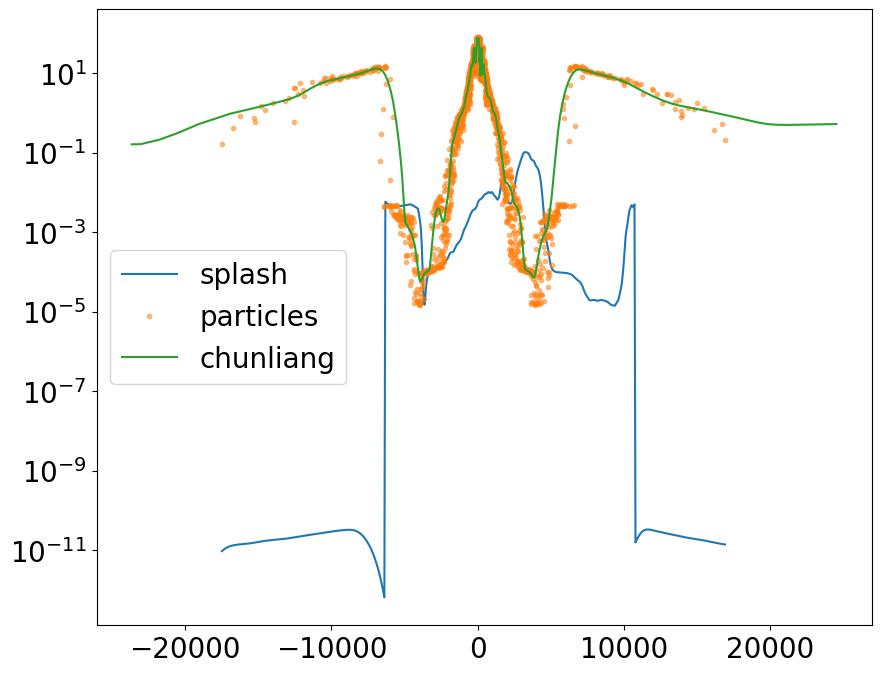

In [21]:
# plot
val='kappa'

valn = val + 's'
# particles values
inds = (sdf['x'] - x)**2 + (sdf['y'] - y)**2 < (kernel_radius * sdf['h'])**2

fig, ax = plt.subplots(figsize=(10, 8))
ax.semilogy(zs1.to(units.Rsun), data[valn][ix, iy].cgs, label="splash")
ax.semilogy(mpdf.get_val('z')[inds].to(units.Rsun), mpdf.get_val(val)[inds].cgs, '.', alpha=0.5, label="particles")
ax.semilogy(pts_waypts[:, 2], clmu_res[valn].cgs, label="chunliang")
ax.legend()

output_dir = f"..{sep}fig{sep}"
fn = f"{output_dir}tmp_{nn}.png"
fig.savefig(fn)

In [27]:
mpdf_val = mpdf.get_val('kappa').cgs
np.min(mpdf_val), np.max(mpdf_val)

(<Quantity 1.26405075e-05 cm2 / g>, <Quantity 117.23265635 cm2 / g>)

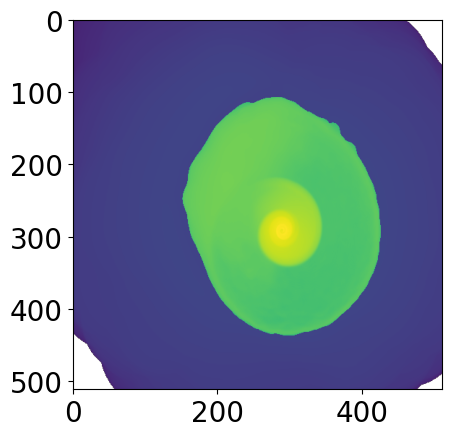

In [20]:
plt.imshow(np.log10(np.sum(data['kappas'].cgs.value, axis=0)))

In [ ]:
plt.imshow(np.sum(data['kappas'].cgs.value, axis=0))

In [37]:
np.max(data['rhos'])

<Quantity 2.984731e-07 g / cm3>